## Creating the geometry and saving to text file


In [2]:
import math

## Vertical
def write_rod_txt(
    filename,
    num_nodes,
    spacing=0.01,
    angle_to_vertical_deg=0.0,
    radial_angle_xy_deg=0.0,
):
    """
    Generate a straight rod in 3D.

    Angles:
        angle_to_vertical_deg:
            polar angle from +z axis.
            0 deg  -> along +z
            90 deg -> lies in xy plane

        radial_angle_xy_deg:
            azimuth angle of the rod projection in the xy plane.
            0 deg  -> +x direction
            90 deg -> +y direction

    Coordinates:
        x = r sin(theta) cos(phi)
        y = r sin(theta) sin(phi)
        z = r cos(theta)
    """

    if num_nodes < 2:
        raise ValueError("num_nodes must be at least 2")

    theta = math.radians(angle_to_vertical_deg)
    phi = math.radians(radial_angle_xy_deg)

    dx = spacing * math.sin(theta) * math.cos(phi)
    dy = spacing * math.sin(theta) * math.sin(phi)
    dz = spacing * math.cos(theta)

    filename = filename.format(angle_to_vertical_deg,radial_angle_xy_deg,num_nodes)


    with open(filename, "w") as f:
        f.write("*Nodes\n")

        for i in range(num_nodes):
            x = i * dx
            y = i * dy
            z = i * dz

            f.write(f"{x:g},{y:g},{z:g}\n")

        f.write("*Edges\n")

        for i in range(1, num_nodes):
            f.write(f"{i},{i + 1}\n")

    print("Saved to:",filename)

def write_rod_txt_h(
    filename,
    num_nodes,
    spacing=0.01,
):
    """
    Generate a straight rod aligned with the +x axis.

    Parameters
    ----------
    filename : str
        Output .txt file.
    num_nodes : int
        Number of nodes.
    spacing : float
        Distance between adjacent nodes.
    """

    if num_nodes < 2:
        raise ValueError("num_nodes must be at least 2")

    with open(filename, "w") as f:
        f.write("*Nodes\n")

        for i in range(num_nodes):
            x = i * spacing
            y = 0.0
            z = 0.0

            f.write(f"{x:.10g},{y:.10g},{z:.10g}\n")

        f.write("*Edges\n")

        for i in range(1, num_nodes):
            f.write(f"{i},{i+1}\n")


#### Inverted U

In [2]:
import numpy as np


def write_inverted_u_txt(
    filename,
    num_nodes,
    arm_length=0.05,
    bend_radius=0.02,
    bend_angle_deg=180,
):
    """
    Generate an inverted-U rod in the x-z plane.

    Shape:
        left vertical arm  -> rounded top bend -> right vertical arm

    Parameters
    ----------
    filename : str
        Output .txt filename.

    num_nodes : int
        Total number of nodes.

    arm_length : float
        Length of each straight vertical arm.

    bend_radius : float
        Radius of the U bend.
        Smaller radius = sharper bend.

    bend_angle_deg : float
        Bend angle. Use 180 for a semicircular inverted U.
        Smaller values make a shallower bend.

    Coordinates:
        x-z plane, y = 0
        z is vertical.
    """

    if num_nodes < 5:
        raise ValueError("num_nodes must be at least 5")

    if arm_length <= 0:
        raise ValueError("arm_length must be positive")

    if bend_radius <= 0:
        raise ValueError("bend_radius must be positive")

    bend_angle = np.deg2rad(bend_angle_deg)

    # Total arc length
    arc_length = bend_radius * bend_angle
    total_length = 2 * arm_length + arc_length

    # Distribute nodes approximately by arclength
    n_left = max(2, round(num_nodes * arm_length / total_length))
    n_arc = max(3, round(num_nodes * arc_length / total_length))
    n_right = num_nodes - n_left - n_arc + 2

    if n_right < 2:
        n_right = 2
        n_arc = num_nodes - n_left - n_right + 2

    nodes = []

    # Left arm: bottom to top
    for i in range(n_left):
        s = i / (n_left - 1)
        x = -bend_radius
        y = 0.0
        z = s * arm_length
        nodes.append([x, y, z])

    # Top inverted-U arc
    # semicircle from left top to right top
    # center at (0, arm_length)
    angles = np.linspace(np.pi, 0, n_arc)

    for theta in angles[1:]:
        x = bend_radius * np.cos(theta)
        y = 0.0
        z = arm_length + bend_radius * np.sin(theta)
        nodes.append([x, y, z])

    # Right arm: top to bottom
    for i in range(1, n_right):
        s = i / (n_right - 1)
        x = bend_radius
        y = 0.0
        z = arm_length * (1 - s)
        nodes.append([x, y, z])

    nodes = np.array(nodes[:num_nodes])

    with open(filename, "w") as f:
        f.write("*Nodes\n")

        for x, y, z in nodes:
            f.write(f"{x:g},{y:g},{z:g}\n")

        f.write("*Edges\n")

        for i in range(1, len(nodes)):
            f.write(f"{i},{i + 1}\n")


import numpy as np


def write_inverted_u_csv(
    filename,
    num_nodes,
    arm_length=0.05,
    bend_radius=0.02,
    bend_angle_deg=180,
):
    """
    Generate an inverted-U curve and save only node coordinates to CSV.

    Output:
        headerless CSV with shape (N_nodes, 3)
        columns: x,y,z
    """

    if num_nodes < 5:
        raise ValueError("num_nodes must be at least 5")

    bend_angle = np.deg2rad(bend_angle_deg)
    arc_length = bend_radius * bend_angle
    total_length = 2 * arm_length + arc_length

    n_left = max(2, round(num_nodes * arm_length / total_length))
    n_arc = max(3, round(num_nodes * arc_length / total_length))
    n_right = num_nodes - n_left - n_arc + 2

    if n_right < 2:
        n_right = 2
        n_arc = num_nodes - n_left - n_right + 2

    nodes = []

    # Left arm: bottom to top
    for i in range(n_left):
        s = i / (n_left - 1)
        nodes.append([-bend_radius, 0.0, s * arm_length])

    # Top arc
    angles = np.linspace(np.pi, 0, n_arc)
    for theta in angles[1:]:
        x = bend_radius * np.cos(theta)
        y = 0.0
        z = arm_length + bend_radius * np.sin(theta)
        nodes.append([x, y, z])

    # Right arm: top to bottom
    for i in range(1, n_right):
        s = i / (n_right - 1)
        nodes.append([bend_radius, 0.0, arm_length * (1 - s)])

    nodes = np.array(nodes[:num_nodes])

    np.savetxt(
        filename,
        nodes,
        delimiter=",",
        fmt="%.10g",
    )



### Bend Straight Rod (.csv)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def read_nodes_from_txt(input_txt):
    nodes = []
    reading_nodes = False

    with open(input_txt, "r") as f:
        for line in f:
            line = line.strip()

            if line == "*Nodes":
                reading_nodes = True
                continue

            if line == "*Edges":
                reading_nodes = False
                continue

            if reading_nodes and line:
                nodes.append([float(v) for v in line.split(",")])

    return np.array(nodes, dtype=float)





def bend_txt_rod_to_inverted_u_csv(
    input_txt,
    output_csv,
    arm_length=0.05,
    bend_radius=0.02,
):
    """
    Bend a straight rod into an inverted-U shape.

    The first node of the bent U is forced to match the first node
    of the original rod.
    """

    nodes = []
    reading_nodes = False

    with open(input_txt, "r") as f:
        for line in f:
            line = line.strip()

            if line == "*Nodes":
                reading_nodes = True
                continue
            elif line == "*Edges":
                reading_nodes = False
                continue

            if reading_nodes and line:
                nodes.append([float(v) for v in line.split(",")])

    nodes = np.array(nodes, dtype=float)
    num_nodes = len(nodes)

    ds = np.linalg.norm(np.diff(nodes, axis=0), axis=1)
    s = np.zeros(num_nodes)
    s[1:] = np.cumsum(ds)

    total_input_length = s[-1]
    if total_input_length <= 0:
        raise ValueError("Input rod has zero length")

    arc_length = np.pi * bend_radius
    target_total_length = 2 * arm_length + arc_length

    s_target = s / total_input_length * target_total_length

    new_nodes = []

    for si in s_target:
        if si <= arm_length:
            x = 0.0
            y = 0.0
            z = si

        elif si <= arm_length + arc_length:
            s_arc = si - arm_length
            theta = np.pi - s_arc / bend_radius

            x = bend_radius + bend_radius * np.cos(theta)
            y = 0.0
            z = arm_length + bend_radius * np.sin(theta)

        else:
            s_right = si - arm_length - arc_length

            x = 2 * bend_radius
            y = 0.0
            z = arm_length - s_right

        new_nodes.append([x, y, z])

    new_nodes = np.array(new_nodes)

    # Shift U so its first node matches original first node
    new_nodes += nodes[0] - new_nodes[0]

    np.savetxt(output_csv, new_nodes, delimiter=",", fmt="%.10g")

    return new_nodes


In [ ]:
# Example
write_inverted_u_txt(
    filename="../tests/resources/pci/inverted_u_n21.txt",
    num_nodes=21,
    arm_length=0.05,
    bend_radius=0.01,   # smaller = sharper U bend
    bend_angle_deg=180,
)

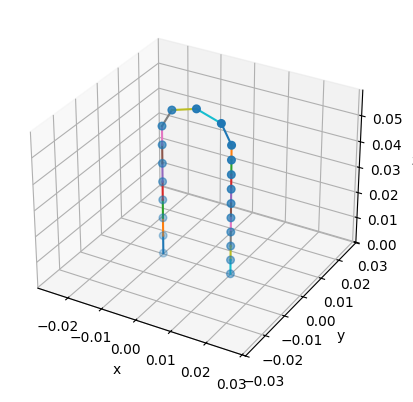

In [269]:
import numpy as np
import matplotlib.pyplot as plt


def plot_nodes_from_txt(input_txt, show_edges=True, equal_axes=True):
    """
    Plot nodes and optional edge connectivity from a .txt file with:
        *Nodes
        x,y,z
        ...
        *Edges
        i,j
        ...

    Assumes edges are 1-indexed.
    """

    nodes = []
    edges = []

    section = None

    with open(input_txt, "r") as f:
        for line in f:
            line = line.strip()

            if line == "*Nodes":
                section = "nodes"
                continue
            elif line == "*Edges":
                section = "edges"
                continue

            if not line:
                continue

            if section == "nodes":
                nodes.append([float(v) for v in line.split(",")])

            elif section == "edges":
                i, j = [int(v) for v in line.split(",")]
                edges.append([i - 1, j - 1])  # convert to 0-index

    nodes = np.array(nodes)
    edges = np.array(edges, dtype=int)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(nodes[:, 0], nodes[:, 1], nodes[:, 2], s=30)

    if show_edges:
        for i, j in edges:
            p0 = nodes[i]
            p1 = nodes[j]
            ax.plot(
                [p0[0], p1[0]],
                [p0[1], p1[1]],
                [p0[2], p1[2]],
            )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    if equal_axes:
        max_range = np.ptp(nodes, axis=0).max()
        center = nodes.mean(axis=0)

        ax.set_xlim(center[0] - max_range / 2, center[0] + max_range / 2)
        ax.set_ylim(center[1] - max_range / 2, center[1] + max_range / 2)
        ax.set_zlim(center[2] - max_range / 2, center[2] + max_range / 2)

    plt.show()


# Example
plot_nodes_from_txt("../tests/resources/pci/inverted_u_n21.txt")

In [3]:
# Example
write_inverted_u_csv(
    filename="../tests/resources/pci/inverted_u_n21.csv",
    num_nodes=21,
    arm_length=0.05,
    bend_radius=0.01,
)

In [20]:
# Example
bend_txt_rod_to_inverted_u_csv(
    input_txt='../tests/resources/pci/angled{}v_azi{}_rod_n{}.txt'.format(angleV, angleAzi, numNodes),
    output_csv="../tests/resources/pci/inverted_u_n21.csv",
    arm_length=0.05,
    bend_radius=0.01,
)

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  6.57078319e-03],
       [ 0.00000000e+00,  0.00000000e+00,  1.31415927e-02],
       [ 0.00000000e+00,  0.00000000e+00,  1.97123233e-02],
       [ 0.00000000e+00,  0.00000000e+00,  2.62831196e-02],
       [ 0.00000000e+00,  0.00000000e+00,  3.28539159e-02],
       [ 0.00000000e+00,  0.00000000e+00,  3.94247122e-02],
       [ 0.00000000e+00,  0.00000000e+00,  4.59954429e-02],
       [ 3.27476063e-04,  0.00000000e+00,  5.25381648e-02],
       [ 3.89182427e-03,  0.00000000e+00,  5.79177136e-02],
       [ 9.99986860e-03,  0.00000000e+00,  6.00000000e-02],
       [ 1.61078116e-02,  0.00000000e+00,  5.79179945e-02],
       [ 1.96724906e-02,  0.00000000e+00,  5.25382919e-02],
       [ 2.00000000e-02,  0.00000000e+00,  4.59959028e-02],
       [ 2.00000000e-02,  0.00000000e+00,  3.94247779e-02],
       [ 2.00000000e-02,  0.00000000e+00,  3.28543101e-02],
       [ 2.00000000e-02,  0.00000000e+00

## Sim Setup

In [129]:
angleV = 1
angleAzi = 90
numNodes = 5

# write_rod_txt(
#     filename='../tests/resources/pci/angled{}v_azi{}_rod_n{}.txt'.format(angleV, angleAzi, numNodes),
#     num_nodes=numNodes,
#     spacing=0.01,
#     angle_to_vertical_deg=angleV,
#     radial_angle_xy_deg=angleAzi,
# )

geom_filename = '../tests/resources/pci/horizontal_rod_n{}.txt'.format(numNodes)
write_rod_txt_h(
    filename=geom_filename,
    num_nodes=numNodes,
    spacing=0.01,
)

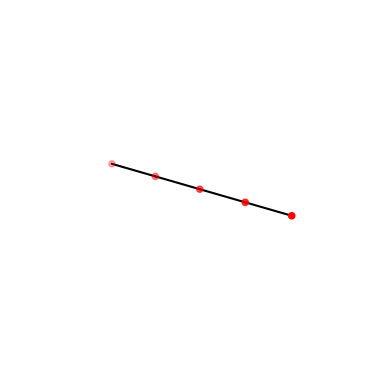

In [155]:
import numpy as np
import dismech

geom = dismech.GeomParams(rod_r0=5e-3,
                          shell_h=0)

material = dismech.Material(density=500,
                            youngs_rod=5e2,
                            youngs_shell=0,
                            poisson_rod=0.5,
                            poisson_shell=0)

dt = 1e-3
dyn_3d_sim = dismech.SimParams(static_sim=False,
                                  two_d_sim=True,
                                  use_mid_edge=False,
                                  use_line_search=False,
                                  show_floor=False,
                                  log_data=True,
                                  log_step=1,
                                  dt=dt,
                                  max_iter=25,
                                  total_time=8,
                                  plot_step=1,
                                  tol=1e-4,
                                  ftol=1e-4,
                                  dtol=1e-2)

env = dismech.Environment()
env.add_force('gravity', g=np.array([0.0, 0.0, -9.81]))


env.add_force('damping', eta=3)
# env.set_static()


# geo = dismech.Geometry.from_txt('../tests/resources/rod_cantilever/vertical_rod_n11.txt')
# geo = dismech.Geometry.from_txt('../tests/resources/pci/angled{}v_azi{}_rod_n{}.txt'.format(angleV, angleAzi, numNodes))
geo = dismech.Geometry.from_txt(geom_filename)

robot = dismech.SoftRobot(geom, material, geo, dyn_3d_sim, env)

fixed_points = np.array([0, 1])
robot = robot.fix_nodes(fixed_points)
stepper = dismech.ImplicitEulerTimeStepper(robot)

## Reference (Target) Shape

### Stretch Rod

In [9]:
import numpy as np


def stretch_nodes_from_txt(
    input_txt,
    output_csv,
    stretch_factor=1.0,
    direction=(1.0, 0.0, 0.0),
):
    """
    Read *Nodes from a rod .txt file and write stretched node coordinates
    to a headerless CSV compatible with:

        r_ref = np.loadtxt(ref_path, delimiter=",")

    Output shape:
        (N_nodes, 3)
    """

    direction = np.array(direction, dtype=float)
    direction /= np.linalg.norm(direction)

    nodes = []
    reading_nodes = False

    with open(input_txt, "r") as f:
        for line in f:
            line = line.strip()

            if line == "*Nodes":
                reading_nodes = True
                continue

            if line == "*Edges":
                reading_nodes = False
                continue

            if reading_nodes and line:
                nodes.append([float(v) for v in line.split(",")])

    nodes = np.array(nodes, dtype=float)

    # Stretch only the component along the specified direction
    stretched_nodes = []
    for p in nodes:
        p_parallel = np.dot(p, direction) * direction
        p_perp = p - p_parallel
        p_new = p_perp + stretch_factor * p_parallel
        stretched_nodes.append(p_new)

    stretched_nodes = np.array(stretched_nodes)

    np.savetxt(
        output_csv,
        stretched_nodes,
        delimiter=",",
        fmt="%.10g",
    )

# Example usage


In [54]:
# input_txt='../tests/resources/pci/angled{}v_azi{}_rod_n{}.txt'.format(angleV, angleAzi, numNodes)
input_txt = geom_filename
output_csv= "../tests/resources/pci/stretched_rod_n{}.csv".format(numNodes)

stretch_nodes_from_txt(
    input_txt= input_txt,
    output_csv=output_csv,
    stretch_factor=3,
    direction=(1, 0, 0),  # stretch along z
)
# Path to your CSV file
# ref_path = "../tests/resources/pci/vertical_stretched2_n11.csv"
# ref_path = "../tests/resources/pci/inverted_u_n21.csv"
ref_path = output_csv


# Read the file (comma-separated, no header)
r_ref = np.loadtxt(ref_path, delimiter=",")

# r_ref: (N_nodes,3)

nodes_ind = robot.stretch_springs.nodes_ind     # (N_edges, 2)
L0        = robot.stretch_springs.ref_len       # (N_edges,)

p0 = r_ref[nodes_ind[:,0]]
p1 = r_ref[nodes_ind[:,1]]
Lref = np.linalg.norm(p1 - p0, axis=1)
eps_ref = Lref / L0 - 1.0  #strains of the new config compared to base

print(eps_ref)
print("min:", eps_ref.min())
print("max:", eps_ref.max())
print("mean:", eps_ref.mean())

[2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
min: 1.9999999999999947
max: 2.000000000000004
mean: 2.0


### Bend Rod into Inverted U

In [ ]:
import numpy as np


def read_nodes_from_txt(input_txt):
    nodes = []
    reading_nodes = False

    with open(input_txt, "r") as f:
        for line in f:
            line = line.strip()

            if line == "*Nodes":
                reading_nodes = True
                continue
            elif line == "*Edges":
                reading_nodes = False
                continue

            if reading_nodes and line:
                nodes.append([float(v) for v in line.split(",")])

    return np.array(nodes, dtype=float)


def bend_straight_rod_to_inverted_u_csv(
    input_txt,
    output_csv,
    bend_node,
    strain=0.10,
    bend_radius=0.02,
    bend_angle_deg=180.0,
    bend_node_is_one_indexed=True,
):
    """
    Bend a straight rod into an inverted-U-like shape.

    Parameters
    ----------
    input_txt : str
        Input .txt file with *Nodes and *Edges.

    output_csv : str
        Output CSV file with only x,y,z nodes.
        No header.

    bend_node : int
        Node where bending begins.

        If bend_node_is_one_indexed=True:
            bend_node=5 means the 5th node in the txt file.

        If bend_node_is_one_indexed=False:
            bend_node=4 means nodes[4].

    strain : float
        Desired positive strain for every segment.
        Example:
            strain=0.10 means every segment is 10% longer.

    bend_radius : float
        Radius of the bend.

    bend_angle_deg : float
        Total bending angle.
        180 deg gives an inverted U.

    Coordinate convention
    ---------------------
    The output starts at the same first node as the input rod.

    Before the bend:
        rod goes along +z

    During bend:
        rod bends in the x-z plane

    After bend:
        rod continues along the final tangent direction.
        For bend_angle_deg=180, this is -z.
    """

    if strain < 0:
        raise ValueError("strain must be nonnegative")

    if bend_radius <= 0:
        raise ValueError("bend_radius must be positive")

    if bend_angle_deg <= 0:
        raise ValueError("bend_angle_deg must be positive")

    nodes = read_nodes_from_txt(input_txt)
    n_nodes = len(nodes)

    if n_nodes < 2:
        raise ValueError("Need at least 2 nodes")

    if bend_node_is_one_indexed:
        bend_idx = bend_node - 1
    else:
        bend_idx = bend_node

    if bend_idx < 0 or bend_idx >= n_nodes:
        raise ValueError("bend_node is out of range")

    # Original segment lengths
    L0_segments = np.linalg.norm(np.diff(nodes, axis=0), axis=1)

    # Stretched target segment lengths
    L_segments = (1.0 + strain) * L0_segments

    bend_angle = np.deg2rad(bend_angle_deg)

    new_nodes = np.zeros_like(nodes)
    new_nodes[0] = nodes[0]

    # beta = current tangent angle from +z toward +x
    # beta = 0      -> +z
    # beta = pi/2   -> +x
    # beta = pi     -> -z
    beta = 0.0

    for i in range(n_nodes - 1):
        L = L_segments[i]

        if i < bend_idx:
            # Straight first arm along +z
            direction = np.array([0.0, 0.0, 1.0])

        elif beta < bend_angle:
            # Bend segment
            if L > 2.0 * bend_radius:
                raise ValueError(
                    f"Segment {i} is too long for bend_radius={bend_radius}. "
                    "Need segment_length <= 2 * bend_radius."
                )

            # Chord angle corresponding to chord length L on radius R
            d_beta = 2.0 * np.arcsin(L / (2.0 * bend_radius))

            # Do not exceed requested total bend angle
            if beta + d_beta > bend_angle:
                d_beta = bend_angle - beta

            # Chord direction is at the mid-angle
            beta_mid = beta + 0.5 * d_beta

            direction = np.array([
                np.sin(beta_mid),
                0.0,
                np.cos(beta_mid),
            ])

            beta += d_beta

        else:
            # Straight second arm after bend
            direction = np.array([
                np.sin(bend_angle),
                0.0,
                np.cos(bend_angle),
            ])

        # Move exactly by stretched segment length
        new_nodes[i + 1] = new_nodes[i] + L * direction

    np.savetxt(
        output_csv,
        new_nodes,
        delimiter=",",
        fmt="%.10g",
    )

    return new_nodes

import numpy as np

def write_nodes_edges_txt(filename, nodes):
    with open(filename, "w") as f:
        f.write("*Nodes\n")

        for x, y, z in nodes:
            f.write(f"{x:.10g},{y:.10g},{z:.10g}\n")

        f.write("*Edges\n")

        for i in range(1, len(nodes)):
            f.write(f"{i},{i + 1}\n")

def bend_straight_rod_to_inverted_u(
    input_txt,
    output_csv,
    output_txt,
    bend_node,
    strain=0.10,
    bend_radius=0.02,
    bend_angle_deg=180.0,
    bend_node_is_one_indexed=True,
):
    nodes = read_nodes_from_txt(input_txt)
    n_nodes = len(nodes)

    if bend_node_is_one_indexed:
        bend_idx = bend_node - 1
    else:
        bend_idx = bend_node

    L0_segments = np.linalg.norm(np.diff(nodes, axis=0), axis=1)
    L_segments = (1.0 + strain) * L0_segments

    bend_angle = np.deg2rad(bend_angle_deg)

    new_nodes = np.zeros_like(nodes)
    new_nodes[0] = nodes[0]

    beta = 0.0

    for i in range(n_nodes - 1):
        L = L_segments[i]

        if i < bend_idx:
            direction = np.array([0.0, 0.0, 1.0])

        elif beta < bend_angle:
            if L > 2.0 * bend_radius:
                raise ValueError(
                    f"Segment {i} is too long for bend_radius={bend_radius}. "
                    "Need segment_length <= 2 * bend_radius."
                )

            d_beta = 2.0 * np.arcsin(L / (2.0 * bend_radius))

            if beta + d_beta > bend_angle:
                d_beta = bend_angle - beta

            beta_mid = beta + 0.5 * d_beta

            direction = np.array([
                np.sin(beta_mid),
                0.0,
                np.cos(beta_mid),
            ])

            beta += d_beta

        else:
            direction = np.array([
                np.sin(bend_angle),
                0.0,
                np.cos(bend_angle),
            ])

        new_nodes[i + 1] = new_nodes[i] + L * direction

    # CSV: nodes only, no header
    np.savetxt(output_csv, new_nodes, delimiter=",", fmt="%.10g")

    # TXT: *Nodes and *Edges
    write_nodes_edges_txt(output_txt, new_nodes)

    return new_nodes

In [7]:
input_txt='../tests/resources/pci/angled{}v_azi{}_rod_n{}.txt'.format(angleV, angleAzi, numNodes)
output_csv= "../tests/resources/pci/inverted_u_n{}.csv".format(numNodes)
output_txt= "../tests/resources/pci/inverted_u_n{}.txt".format(numNodes)
bend_node =  3 # numNodes //2 -1


bend_straight_rod_to_inverted_u(
    input_txt= input_txt,
    output_csv= output_csv,
    output_txt=output_txt,
    bend_node=bend_node,          # bending starts at node 9
    strain=0.10,          # 10% positive strain on all segments
    bend_radius=0.01,
    bend_angle_deg=180.0,
)


array([[ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.011     ],
       [ 0.        ,  0.        ,  0.02200005],
       [ 0.00604991,  0.        ,  0.03118682],
       [ 0.01687945,  0.        ,  0.02925768],
       [ 0.02122449,  0.        ,  0.01915218],
       [ 0.02122449,  0.        ,  0.00815215],
       [ 0.02122449,  0.        , -0.00284776]])

### 90 degree bend up and down, and dummy robot and json function defs

In [24]:
import numpy as np


def write_bent_rod_txt(
    filename,
    num_nodes,
    bend_node,
    spacing=0.01,
    bend_angle_deg=90.0,
    bend_plane="xy",
    bend_direction="+",
):
    """
    Generate a rod that is initially aligned along +x, then bends at a given node.

    Parameters
    ----------
    filename : str
        Output .txt filename.

    num_nodes : int
        Total number of nodes.

    bend_node : int
        Node where the rod bends. This is 1-indexed.
        Example: bend_node=4 means the 4th node is the corner.

    spacing : float
        Distance between adjacent nodes.

    bend_angle_deg : float
        Bend angle in degrees. Must be between 0 and 180.
        0   -> no bend, continues along +x
        90  -> perpendicular bend
        180 -> folds back along -x

    bend_plane : str
        Plane in which the bent portion lies.
        Options:
            "xy" -> bend toward +/- y
            "xz" -> bend toward +/- z
            "zy" -> bend in yz plane after the bend node

        Note:
            Since the unbent rod is along x, the most natural planes are
            "xy" and "xz". For "zy", the post-bend segment is placed in
            the yz plane starting from the bend node.

    bend_direction : str
        Direction of bending.
        Use "+" or "-".

        For bend_plane="xy":
            "+" -> toward +y
            "-" -> toward -y

        For bend_plane="xz":
            "+" -> toward +z
            "-" -> toward -z

        For bend_plane="zy":
            "+" -> toward +z
            "-" -> toward -z
    """

    if num_nodes < 2:
        raise ValueError("num_nodes must be at least 2")

    if bend_node <= 2:
        raise ValueError("bend_node must be > 2")

    if bend_node > num_nodes:
        raise ValueError("bend_node must be <= num_nodes")

    if not (0.0 <= bend_angle_deg <= 180.0):
        raise ValueError("bend_angle_deg must be between 0 and 180 degrees")

    if bend_plane not in ["xy", "xz", "zy"]:
        raise ValueError("bend_plane must be one of: 'xy', 'xz', 'zy'")

    if bend_direction not in ["+", "-"]:
        raise ValueError("bend_direction must be '+' or '-'")

    sign = 1.0 if bend_direction == "+" else -1.0
    theta = np.deg2rad(bend_angle_deg)

    nodes = []

    # First arm: aligned along +x
    for i in range(bend_node):
        x = i * spacing
        y = 0.0
        z = 0.0
        nodes.append([x, y, z])

    bend_point = np.array(nodes[-1])

    # Direction of the rod after the bend
    if bend_plane == "xy":
        direction = np.array([
            np.cos(theta),
            sign * np.sin(theta),
            0.0,
        ])

    elif bend_plane == "xz":
        direction = np.array([
            np.cos(theta),
            0.0,
            sign * np.sin(theta),
        ])

    elif bend_plane == "zy":
        # post-bend portion lies in yz plane, no further x motion
        # angle is measured away from +y toward +/- z
        direction = np.array([
            0.0,
            np.cos(theta),
            sign * np.sin(theta),
        ])

    # Second arm
    for i in range(bend_node, num_nodes):
        s = (i - bend_node + 1) * spacing
        p = bend_point + s * direction
        nodes.append(p.tolist())

    nodes = np.array(nodes)

    with open(filename, "w") as f:
        f.write("*Nodes\n")

        for x, y, z in nodes:
            f.write(f"{x:.10g},{y:.10g},{z:.10g}\n")

        f.write("*Edges\n")

        for i in range(1, num_nodes):
            f.write(f"{i},{i + 1}\n")

    return nodes

In [134]:
def dummy_robot(bent_rod_filename):

    geom_b = dismech.GeomParams(rod_r0=5e-3,
                            shell_h=0)

    material_b = dismech.Material(density=500,
                                youngs_rod=5e4,
                                youngs_shell=0,
                                poisson_rod=0.5,
                                poisson_shell=0)

    dt = 1e-3
    dyn_3d_sim_b = dismech.SimParams(static_sim=False,
                                    two_d_sim=False,
                                    use_mid_edge=False,
                                    use_line_search=False,
                                    show_floor=False,
                                    log_data=True,
                                    log_step=1,
                                    dt=dt,
                                    max_iter=25,
                                    total_time=0.1,
                                    plot_step=1,
                                    tol=1e-4,
                                    ftol=1e-4,
                                    dtol=1e-2)

    env_b = dismech.Environment()

    # geo = dismech.Geometry.from_txt('../tests/resources/rod_cantilever/vertical_rod_n11.txt')
    geo_b = dismech.Geometry.from_txt(bent_rod_filename)

    robot_b= dismech.SoftRobot(geom_b, material_b, geo_b, dyn_3d_sim_b, env_b)

    return robot_b

In [27]:
import json
import matplotlib.pyplot as plt

def save_robot_state_to_json(state, filename="final_state.json"):
    """
    Save the entire RobotState object to a JSON file.
    Automatically converts numpy arrays to lists.
    """
    state_dict = {}

    # loop through all attributes of the state
    for attr in dir(state):
        # skip private attributes and methods
        if attr.startswith("_"):
            continue
        val = getattr(state, attr)

        # skip callables (methods, properties that are functions)
        if callable(val):
            continue

        # convert numpy arrays to lists for JSON serialization
        if isinstance(val, np.ndarray):
            state_dict[attr] = val.tolist()
        else:
            # handle nested numpy arrays or None/float/int
            try:
                json.dumps(val)  # test if JSON serializable
                state_dict[attr] = val
            except TypeError:
                # fallback for unknown types (e.g., other custom objects)
                state_dict[attr] = str(val)

    # write to JSON
    with open(filename, "w") as f:
        json.dump(state_dict, f, indent=2)

def plot_original_and_bent(input_txt, bent_csv):
    """
    Plot original rod from .txt and bent rod from headerless .csv side by side.
    """

    original_nodes = read_nodes_from_txt(input_txt)
    bent_nodes = np.loadtxt(bent_csv, delimiter=",")

    fig = plt.figure(figsize=(10, 4))

    ax1 = fig.add_subplot(121, projection="3d")
    ax2 = fig.add_subplot(122, projection="3d")

    def plot_nodes(ax, nodes, title):
        ax.scatter(nodes[:, 0], nodes[:, 1], nodes[:, 2], s=25)
        ax.plot(nodes[:, 0], nodes[:, 1], nodes[:, 2])

        ax.set_title(title)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("z")

        max_range = np.ptp(nodes, axis=0).max()
        center = nodes.mean(axis=0)

        ax.set_xlim(center[0] - max_range / 2, center[0] + max_range / 2)
        ax.set_ylim(center[1] - max_range / 2, center[1] + max_range / 2)
        ax.set_zlim(center[2] - max_range / 2, center[2] + max_range / 2)

    plot_nodes(ax1, original_nodes, "Original rod")
    plot_nodes(ax2, bent_nodes, "Bent inverted-U rod")

    plt.tight_layout()
    plt.show()

## Target Shape: bent rod -> dummy robot -> json state saving -> eps and kappa ref

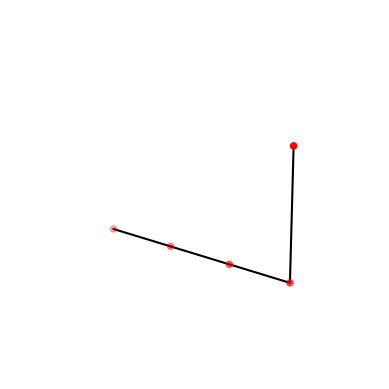

Reference bending strain: [[ 0. -0.]
 [ 0. -0.]
 [ 2. -0.]]
Reference stretching strain: [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 -1.11022302e-16]


In [ ]:
## Bent rod to kappa and eps ref pipeline
import json
import numpy as np
from types import SimpleNamespace

bend_plane = "xz"
bend_direction = "+"
bend_dict = {"+": "pos", "-": "neg"}
bent_node = 4
bent_rod_filename = '../tests/resources/pci/bent_rod__plane_{}__direction_{}_bendNode_{}__nodes_{}.txt'.format(bend_plane, bend_dict[bend_direction], bent_node, numNodes)

write_bent_rod_txt(
    filename=bent_rod_filename,
    num_nodes=numNodes,
    bend_node=bent_node,
    spacing=0.01,
    bend_angle_deg=90,
    bend_plane=bend_plane,
    bend_direction=bend_direction,
)

robot_b = dummy_robot(bent_rod_filename)
shape_json = "final_state{}.json".format(numNodes)
final_state = robot_b.state
save_robot_state_to_json(final_state,shape_json)


def dict_to_state_namespace(d):
    # convert lists -> np.array where appropriate
    cooked = {}
    for k, v in d.items():
        cooked[k] = np.array(v) if isinstance(v, list) else v
    return SimpleNamespace(**cooked)

with open(shape_json, "r") as f:
    ref_state_dict = json.load(f)

ref_state = dict_to_state_namespace(ref_state_dict)

be = stepper.elastic_energies['bend']
se = stepper.elastic_energies['stretch']

kappa_ref = be.get_strain(ref_state)
eps_ref = se.get_strain(ref_state)
print("Reference bending strain:", kappa_ref)
print("Reference stretching strain:", eps_ref)

### before step functions

In [ ]:
Kp = 5
Ki = 100
Kd = 1

Kp_kappa = 0.001
Ki_kappa = 0
Kd_kappa = 0


nat0 = robot.stretch_springs.nat_strain.copy()  # shape (N_edges,)
eps_ref0 = np.zeros(eps_ref.shape)
stretch_pid  = LongitudinalPI(eps_ref, nat0, Kp=Kp, Ki=Ki, Kd=Kd,
                        du_rate=0.02, smooth_alpha=0.10)


In [ ]:
def update_EA(robot: dismech.SoftRobot, t: float):
    tstep =int( t/dt)

    num_active = min((tstep // dtrate) + 1, nlenEA) # Determines the rate of travel of the air bubble. Right now it is travelling a rod length every 100 timesteps. This needs to grounded in the real flow rate and the air bubble travel rate
    current_active = int(np.sum(EA_spatial))

    # Only update if num_active changed
    if num_active > current_active:

        EA_spatial[current_active:num_active] = 1

        EA_added = np.zeros(nlenEA)
        EA_added[current_active:num_active] = 1

        EI_added = np.zeros((nlenEI,1))
        EI_added[current_active:num_active] = 1

        robot.stretch_springs.EA += EA_added * EA0
        robot.bend_springs.EI += EI_added * EI0

    return robot

def before_step_fn(rb, t):
    global EI_activation
    tstep =int( t/dt)

    num_active = min((tstep // dtrate) + 1, nlenEA) # Determines the rate of travel of the air bubble. Right now it is travelling a rod length every drate timesteps. This needs to grounded in the real flow rate and the air bubble travel rate
    current_active = int(np.sum(EA_spatial))

    # fetch StretchEnergy from the stepper on every call (cheap)
    stretch_energy = stepper.elastic_energies['stretch']
    bend_energy = stepper.elastic_energies['bend']

    # 1) measure current edge strains from the current state
    eps_meas = stretch_energy.get_strain(rb.state)  # (N_edges,)
    kappa_meas = bend_energy.get_strain(rb.state)

    # Only update eps_ref in pid object if num_active changed
    if num_active > current_active:

        EA_spatial[0:num_active] = 1
        EI_spatial[0:num_active,0:2] = 1

        EA_added = np.zeros(nlenEA)
        EA_added[current_active:num_active] = 1

        EI_added = np.zeros((nlenEI,1))
        EI_added[current_active:num_active] = 1

        EA_rev = 1 - EA_spatial
        EI_rev = 1 - EI_spatial

        rb.stretch_springs.EA += EA_added * EA0
        # rb.bend_springs.EI += EI_added * EI0
        stretch_pid.eps_ref =  eps_ref*EA_spatial + eps_meas*EA_rev # eps_ref0
        # curv_pid.kappa_ref = kappa_ref*EI_spatial + kappa_meas*EI_rev  #

        print("EA_spatial:", EA_spatial)
        # print("EI_spatial:", EI_spatial)
        # print("EA_added:", EA_added)
        # print("EA rev :", EA_rev)
        # print("Sliced eps_meas",eps_meas*EA_rev)
        # print("Sliced kappa_ref",kappa_ref*EI_spatial)
        # print("Sliced kappa_meas",kappa_meas*EI_rev)
        # print("kappa ref new",curv_pid.kappa_ref  )
        # print("eps_ref New",stretch_pid.eps_ref  )
        # print("eps meas", eps_meas)

    EI_activation = np.minimum(
                        EI_activation + EI_ramp_rate * EI_spatial,
                        EI_spatial
                        )

    rb.bend_springs.EI[:] = EI_base * (1.0 + stiffen_b * EI_activation)

    EI_rev = 1 - EI_spatial
    curv_pid.kappa_ref = kappa_ref * EI_activation + kappa_meas * (1 - EI_activation)

    # 2) PI update on natural strain (in-place write)
    stretch_pid.update(eps_meas, rb.stretch_springs.nat_strain, dt)
    curv_pid.update(kappa_meas, rb.bend_springs.nat_strain, dt)


    kappa_err = np.linalg.norm(kappa_meas - kappa_ref) / np.sqrt(len(kappa_meas))
    bend_strain_errors.append(kappa_err)

    eps_err = np.linalg.norm(eps_meas - eps_ref) / np.sqrt(len(eps_meas))
    stretch_strain_errors.append(eps_err)
    # print the error between target and measured strain
    # print(f"t={t:.3f}, ||eps-eps_ref||={err:.6f}")

    # also print the error between the state and the reference (nodal positions)
    curr_pos = rb.state.q[0:rb.end_node_dof_index] # (N_nodes*3,)
    ref_pos = ref_state.q[0:rb.end_node_dof_index] # (N_nodes*3,)
    pos_err = np.linalg.norm(curr_pos - ref_pos) / np.sqrt(len(curr_pos))
    # print(f"t={t:.3f}, ||pos-ref_pos||={pos_err:.6f}")
    pos_errors.append(pos_err)

    # print(f"t={t:.3f}, ||pos-ref_pos||={pos_err:.6f}")

    # save this pos_err for later plotting
    pos_errors.append(pos_err)

    return rb

## PID: Increment stiffness and ref_strain across length of rod 

In [156]:
from dismech.controllers.longitudinalPI import LongitudinalPI
from dismech.controllers.curvaturePI import CurvaturePI

# ── Scale everything to a 800 s ramp (100× the original 8 s) ─────────────────
scale = 1
# Extend total simulation time
dyn_3d_sim.total_time = dyn_3d_sim.total_time * scale        # robot.sim_params.total_time updates automatically


# Scale per-element activation ramp rates
EI_ramp_rate   = 0.01 / scale        # 1e-5
EA_ramp_rate   = 0.01 / scale        # 1e-5
EI_p_ramp_rate = 0.5   / scale        # 5e-3  — drives gradual kappa_ref via EI_activation_p

stiffen_s = 500
stiffen_b = 10000

# Scale spatial bubble propagation rate (1 element activates per dtrate timesteps)
dtrate = 1000 * scale                  # 100_000 timesteps per element = same fraction of total_time

nlenEA =  robot.stretch_springs.EA.shape[0]
nlenEI = robot.bend_springs.EI.shape[0]
EA0 = robot.stretch_springs.EA[0]*stiffen_s
EI0 = robot.bend_springs.EI[0]*stiffen_b


EI_base = robot.bend_springs.EI.copy()
EI_spatial = np.zeros_like(robot.bend_springs.EI)
EI_activation = np.zeros_like(robot.bend_springs.EI)
EI_activation_p = np.zeros_like(robot.bend_springs.EI)

EA_base = robot.stretch_springs.EA.copy()
EA_spatial = np.zeros(nlenEA)
EA_activation = np.zeros_like(robot.stretch_springs.EA)

EI_arr = np.zeros(((int(dyn_3d_sim.total_time / dyn_3d_sim.dt)+2),nlenEI,2))

apply_kappa = True
apply_stretch = False
apply_EAEI = True


if apply_kappa:
    Kp_kappa = 0.01
    Ki_kappa = 0.2
    Kd_kappa = 0
    
    curv_nat0 = robot.bend_springs.nat_strain.copy()
    kappa_ref0 = np.zeros(kappa_ref.shape)
    curv_pid = CurvaturePI(kappa_ref, curv_nat0,
                        Kp=Kp_kappa, Ki=Ki_kappa, Kd=Kd_kappa,     # keep Kd=0 unless you use velocity-based damping
                        du_rate=0.10,                # per-step max |Δ nat curvature|
                        smooth_alpha=0.20,
                        kappa_max=np.inf)
    
if apply_stretch:
    Kp_stretch = 5
    Ki_stretch = 100
    Kd_stretch = 1
    nat0 = robot.stretch_springs.nat_strain.copy()  # shape (N_edges,)
    eps_ref0 = np.zeros(eps_ref.shape)
    stretch_pid  = LongitudinalPI(eps_ref, nat0, Kp=Kp_stretch, Ki=Ki_stretch, Kd=Kd_stretch,
                            du_rate=0.02, smooth_alpha=0.10)

dt = dyn_3d_sim.dt
stretch_energy = None
pos_errors = []
stretch_strain_errors = []
bend_strain_errors = []

t_stab = 1000

def update_EIEA(robot: dismech.SoftRobot, t: float):
    tstep  = int(t / dt)
    if tstep > t_stab:
        num_active     = min((tstep // dtrate) + 1, nlenEI)
        current_active = int(np.sum(EI_spatial[:, 0]))

        bend_energy    = stepper.elastic_energies['bend']
        stretch_energy = stepper.elastic_energies['stretch']
        kappa_meas     = bend_energy.get_strain(robot.state)
        eps_meas       = stretch_energy.get_strain(robot.state)

        if num_active > current_active:
            print(num_active, current_active)
            EI_spatial[0:num_active, 0:2] = 1
            EA_spatial[0:num_active]      = 1

        EI_activation[:] = np.minimum(
            EI_activation + EI_ramp_rate * EI_spatial, 1.0)

        EI_activation_p[:] = np.minimum(
            EI_activation_p + EI_p_ramp_rate * EI_spatial, 1.0)

        EA_activation[:] = np.minimum(
            EA_activation + EA_ramp_rate * EA_spatial, 1.0)

        if apply_EAEI:
            robot.bend_springs.EI[:]    = EI_base + EI_activation * EI0
            robot.stretch_springs.EA[:] = EA_base + EA_activation * EA0

        if apply_kappa:
            # Gradual kappa_ref ramp via EI_activation_p (was binary EI_spatial)
            curv_pid.kappa_ref = kappa_ref * EI_activation_p + kappa_meas * (1 - EI_activation_p)
            curv_pid.update(kappa_meas, robot.bend_springs.nat_strain, dt)

            kappa_err = np.linalg.norm(kappa_meas - kappa_ref) / np.sqrt(len(kappa_meas))
            bend_strain_errors.append(kappa_err)

            if num_active + 1 == bent_node:
                print("kappa_ref:", curv_pid.kappa_ref)
                print("kappa_meas:", kappa_meas)
                print("EI_spatial:", EI_spatial)
                print("bend_springs:", robot.bend_springs.EI )

        if apply_stretch:
            stretch_pid.eps_ref = eps_ref * EA_spatial + eps_meas * (1 - EA_spatial)
            stretch_pid.update(eps_meas, robot.stretch_springs.nat_strain, dt)
            eps_err = np.linalg.norm(eps_meas - eps_ref) / np.sqrt(len(eps_meas))
            stretch_strain_errors.append(eps_err)
            print("eps_ref:", stretch_pid.eps_ref)
            print("EA_spatial:", EA_spatial)

    EI_arr[tstep, :, :] = robot.bend_springs.EI[:]
    return robot

stepper.before_step = update_EIEA


def update_EIEA_old(robot: dismech.SoftRobot, t: float):
    # apply_kappa = False

    tstep =int( t/dt)
    t_stab = 1000
    if tstep>t_stab:
        num_active = min((tstep // dtrate) + 1, nlenEI) # Determines the rate of travel of the air bubble. Right now it is travelling a rod length every 100 timesteps. This needs to grounded in the real flow rate and the air bubble travel rate
        current_active = int(np.sum(EI_spatial[:,0]))

        bend_energy = stepper.elastic_energies['bend']
        stretch_energy = stepper.elastic_energies['stretch']
        kappa_meas = bend_energy.get_strain(robot.state)
        eps_meas = stretch_energy.get_strain(robot.state)

        # Only update if num_active changed
        if num_active > current_active:
            print(num_active, current_active)

            EI_spatial[0:num_active,0:2] = 1
            EA_spatial[0:num_active] = 1

        EI_activation[:] = np.minimum(
                        EI_activation + EI_ramp_rate * EI_spatial,1.0,)
        # print("EI_spatial:", EI_spatial)
        # print("EI_activation:", EI_activation)


        EI_activation_p[:] = np.minimum(
                        EI_activation_p + EI_p_ramp_rate * EI_spatial,1.0,)
        

        EA_activation[:] = np.minimum(
                        EA_activation + EA_ramp_rate * EA_spatial,1.0,)

        if apply_EAEI:
            robot.bend_springs.EI[:] = EI_base + EI_activation * EI0
            robot.stretch_springs.EA[:] = EA_base + EA_activation * EA0

        if apply_kappa:
            # curv_pid.kappa_ref = kappa_ref * EI_activation_p + kappa_meas * (1 - EI_activation_p)
            curv_pid.kappa_ref = kappa_ref * EI_spatial + kappa_meas * (1 - EI_spatial)
            curv_pid.update(kappa_meas, robot.bend_springs.nat_strain, dt)

            kappa_err = np.linalg.norm(kappa_meas - kappa_ref) / np.sqrt(len(kappa_meas))
            bend_strain_errors.append(kappa_err)

            aa = int(np.sum(curv_pid.kappa_ref))
            if num_active -1 == bent_node:
                # print("")
                print("kappa_ref:", curv_pid.kappa_ref)
                print("kappa_meas:", kappa_meas)
                # kappa_ref_new = kappa_ref * EI_spatial + kappa_meas * (1 - EI_spatial)
                # print("kappa_ref new:", kappa_ref_new)

        if apply_stretch:
            stretch_pid.eps_ref =  eps_ref*EA_spatial + eps_meas*(1-EA_spatial) # eps_ref0
            stretch_pid.update(eps_meas, robot.stretch_springs.nat_strain, dt)
            eps_err = np.linalg.norm(eps_meas - eps_ref) / np.sqrt(len(eps_meas))
            stretch_strain_errors.append(eps_err)
            print("eps_ref:", stretch_pid.eps_ref)
            print("EA_spatial:", EA_spatial)
        


    EI_arr[tstep,:,:] = robot.bend_springs.EI[:]

    return robot


stepper.before_step = update_EIEA

robots, t_arr, f_norms = stepper.simulate()
qs = np.stack([robot.state.q for robot in robots])
vs = np.stack([robot.state.u for robot in robots])
EI_arr[len(robots)-1,:,:] = robot.bend_springs.EI[:]
t_arr = np.array(t_arr)

iter: 1, error: 0.012
iter: 2, error: 0.000
current_time:  0.001
iter: 1, error: 0.023
iter: 2, error: 0.000
current_time:  0.002
iter: 1, error: 0.033
iter: 2, error: 0.000
current_time:  0.003
iter: 1, error: 0.043
iter: 2, error: 0.000
current_time:  0.004
iter: 1, error: 0.053
iter: 2, error: 0.000
current_time:  0.005
iter: 1, error: 0.062
iter: 2, error: 0.000
current_time:  0.006
iter: 1, error: 0.071
iter: 2, error: 0.000
current_time:  0.007
iter: 1, error: 0.080
iter: 2, error: 0.000
current_time:  0.008
iter: 1, error: 0.088
iter: 2, error: 0.000
current_time:  0.009000000000000001
iter: 1, error: 0.096
iter: 2, error: 0.000
current_time:  0.010000000000000002
iter: 1, error: 0.103
iter: 2, error: 0.000
current_time:  0.011000000000000003
iter: 1, error: 0.110
iter: 2, error: 0.000
current_time:  0.012000000000000004
iter: 1, error: 0.117
iter: 2, error: 0.000
current_time:  0.013000000000000005
iter: 1, error: 0.123
iter: 2, error: 0.000
current_time:  0.014000000000000005


In [157]:
# options = dismech.AnimationOptions(title='Rod (N=11)) Vertical Angle {} Azimuth {}'.format(angleV, angleAzi), plot_step=10)

options = dismech.AnimationOptions(title='Rod (N={})) Horizontal'.format(numNodes), plot_step=10)


fig = dismech.get_interactive_animation_plotly(robot, t_arr, qs, options)
fig.show()


In [276]:
t_arr.shape

(7001,)

## Stiffness Plots

ValueError: x and y must have same first dimension, but have shapes (7001,) and (7002,)

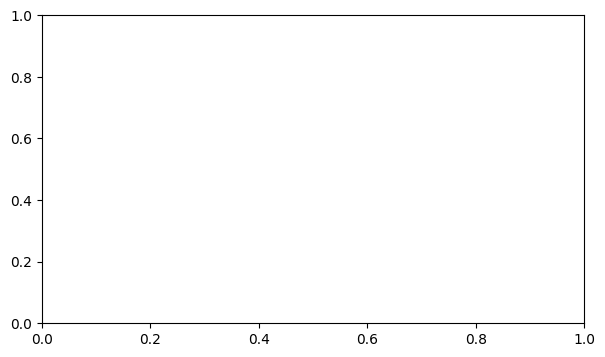

In [275]:
import matplotlib.pyplot as plt

edge_idx = 0

plt.figure(figsize=(7, 4))
plt.plot(t_arr, EI_arr[:, edge_idx, 1])

plt.xlabel("Time (s)")
plt.ylabel("Bending stiffness, EI")
plt.title(f"Bending stiffness over time: edge {edge_idx}")
plt.grid(True)
plt.tight_layout()
plt.show()

## Error Plots

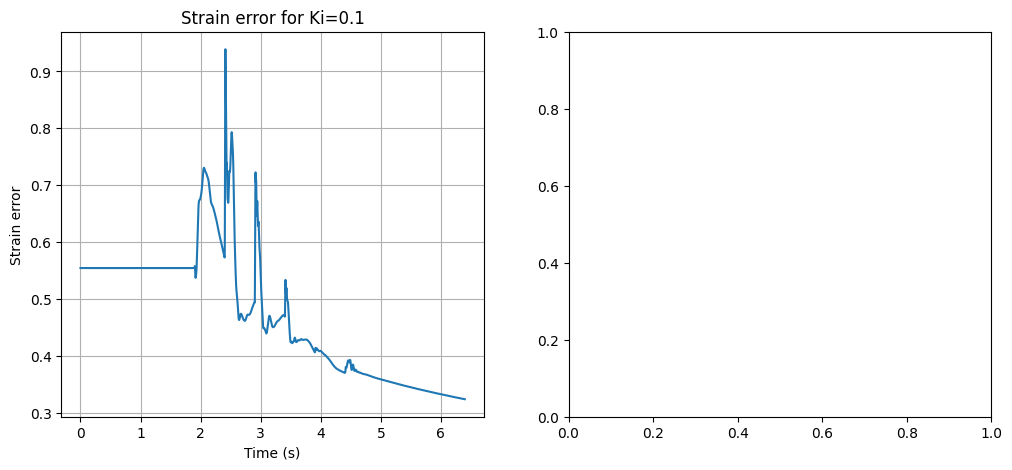

In [318]:
# t = np.arange(robot.sim_params.total_time, step=robot.sim_params.dt)
n = len(bend_strain_errors)
dt = robot.sim_params.dt

t = np.arange(n) * dt

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
# make the strain error and position error plots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(t, bend_strain_errors, label='Bending')
# ax1.plot(t, stretch_strain_errors, label='Stretching')
ax1.set_title("Strain error for Ki={Ki}".format(Ki=Ki_kappa))
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Strain error")
ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax1.grid(True)


# ax2.plot(t, pos_errors, color='orange')
# ax2.set_title("Position error for Kd={Kd}".format(Kd=Kd_kappa))
# ax2.set_xlabel("Time (s)")
# ax2.set_ylabel("Position error (m)")
# ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
# ax2.grid(True)
# plt.tight_layout()
# plt.show()

### Save Final State

In [ ]:


# --- usage ---
final_state = robot_b.state
save_robot_state_to_json(final_state, "inv_u_n.json")
print("Saved full state to final_state_new.json")

Saved full state to final_state_new.json
